In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv(r"D:\SEM_VI\PATTERN_REC\Housing.csv")

# encode categoricals (same as P2)
cat_cols = ['mainroad','guestroom','basement',
            'hotwaterheating','airconditioning',
            'prefarea','furnishingstatus']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# use only area vs price (keep it simple)
X = df[['area']].values
y = df['price'].values.reshape(-1, 1)

In [3]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [4]:
def gradient_descent(X, y, lr=0.1, epochs=500):
    m = len(X)
    X_b = np.hstack([np.ones((m, 1)), X])  # add bias column of 1s
    theta = np.zeros((2, 1))               # start weights at 0
    costs = []

    for i in range(epochs):
        y_pred = X_b @ theta               # predictions
        error = y_pred - y                 # error
        cost = (1/(2*m)) * np.sum(error**2)# MSE cost
        gradient = (1/m) * X_b.T @ error  # gradient
        theta = theta - lr * gradient     # update weights
        costs.append(cost)

    return theta, costs

Theta: [7.89732862e-17 5.35997346e-01]


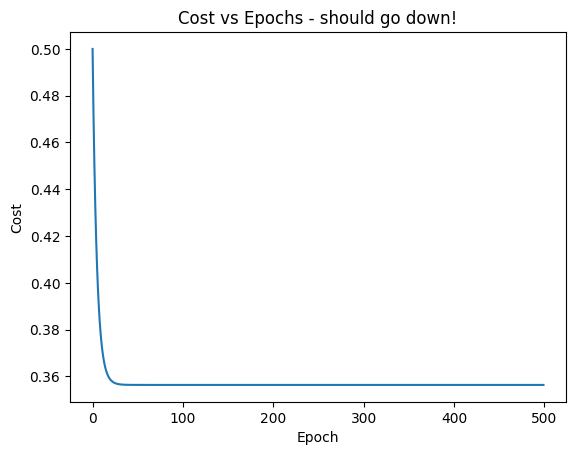

R2 Score: 0.2873


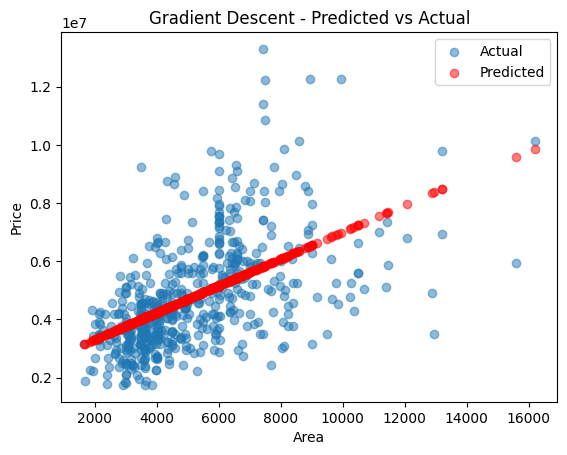

In [5]:
theta, costs = gradient_descent(X_scaled, y_scaled, lr=0.1, epochs=500)
print(f'Theta: {theta.flatten()}')

# Plot cost going down
plt.plot(costs)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Cost vs Epochs - should go down!')
plt.show()

# Predictions
m = len(X_scaled)
X_b = np.hstack([np.ones((m, 1)), X_scaled])
y_pred_scaled = X_b @ theta

# inverse transform to get real prices
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_scaled)

print(f'R2 Score: {r2_score(y_actual, y_pred):.4f}')

# Plot trend line
plt.scatter(X, y_actual, alpha=0.5, label='Actual')
plt.scatter(X, y_pred, alpha=0.5, color='red', label='Predicted')
plt.xlabel('Area')
plt.ylabel('Price')
plt.legend()
plt.title('Gradient Descent - Predicted vs Actual')
plt.show()